In [1]:
import sys 
sys.path.append('..')
from csbm import *
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
color_list=['#2a557f','#46bd9c','#ef5076','#facd6e']
color_list_two=[(7/255,7/255,7/255),(255/255,59/255,59/255)]

In [4]:
clist=np.arange(-4,2,0.3)
inum=len(clist)
repeat=10
r_testacc=np.zeros((inum,repeat))
r_trainacc=np.zeros((inum,repeat))
r_testrisk=np.zeros((inum,repeat))
r_trainrisk=np.zeros((inum,repeat))
r_loss=np.zeros((inum,repeat))
for i, c in enumerate(tqdm(clist)):
    for ri in range(repeat):
        N=5000
        d=30
        gamma=5
        alpha=1/gamma
        lam=-2
        mu=0
        r=0
        tau=0.8
        A,X,y=CSBM(N,alpha,d,lam,mu,matrix='BN',genX=True)
        A=A+c*np.eye(N)
        r_trainacc[i,ri], r_testacc[i,ri],  r_trainrisk[i,ri], r_testrisk[i,ri], r_loss[i,ri]=LS(A,X,y,r,tau=tau)

100%|██████████| 20/20 [05:24<00:00, 16.22s/it]


In [4]:
# load from mathmatica

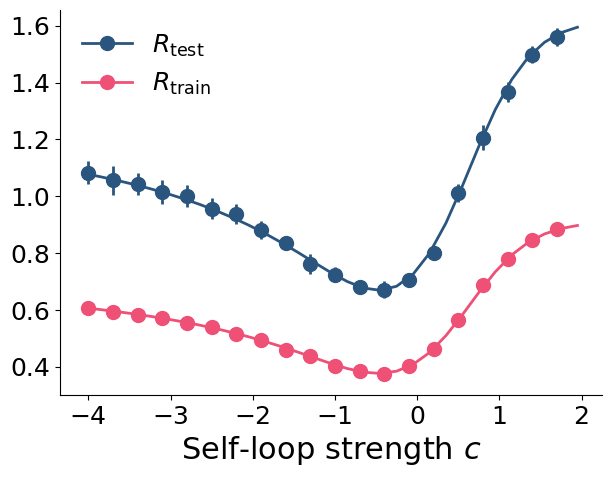

In [6]:
plt.rcParams["figure.figsize"] = (7,5)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()


dashes=[5,3]
legend_list=[]
p1=ax.plot(clistT,testT,'-',linewidth=2,color=color_list[0])
p2=ax.errorbar(clist,r_testrisk.mean(axis=1),r_testrisk.std(axis=1),fmt='o',color=color_list[0],capsize=0, elinewidth=2,markersize=10)
legend_list.append((p2[0], p1[0]))

p3=ax.plot(clistT,trainT,'-',linewidth=2,color=color_list[-2])
p4=ax.errorbar(clist,r_trainrisk.mean(axis=1),r_trainrisk.std(axis=1),fmt='o',color=color_list[-2],capsize=0, elinewidth=2,markersize=10)
legend_list.append((p3[0], p4[0]))
ax.legend(legend_list, [r'$R_{\mathrm{test}}$',r'$R_{\mathrm{train}}$'],frameon=False,fontsize=18)

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')




#ax.set_ylim(-0.1,5)
#ax.set_xlim(0,1)
ax.set_xlabel(r'Self-loop strength $c$',fontsize=22)
fig.savefig('f_selfloop_1.pdf',bbox_inches='tight')

In [12]:
re=[]
lambdalist=[-1,0,1,2]
for lam in lambdalist:
    clist=np.arange(-2,4,0.3)
    inum=len(clist)
    repeat=10
    r_testacc=np.zeros((inum,repeat))
    r_trainacc=np.zeros((inum,repeat))
    r_testrisk=np.zeros((inum,repeat))
    r_trainrisk=np.zeros((inum,repeat))
    r_loss=np.zeros((inum,repeat))
    for i, c in enumerate(tqdm(clist)):
        for ri in range(repeat):
            N=5000
            d=30
            gamma=5
            alpha=1/gamma
            #lam=1
            mu=0
            r=0
            tau=0.8
            A,X,y=CSBM(N,alpha,d,lam,mu,matrix='BN',genX=True)
            A=A+c*np.eye(N)
            r_trainacc[i,ri], r_testacc[i,ri],  r_trainrisk[i,ri], r_testrisk[i,ri], r_loss[i,ri]=LS(A,X,y,r,tau=tau)
    re.append(r_testrisk)

100%|██████████| 20/20 [05:24<00:00, 16.24s/it]


In [ ]:
# load from mathmatica

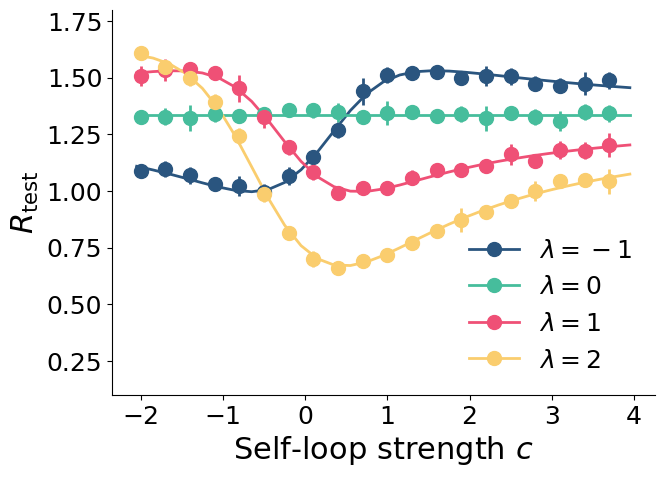

In [9]:
plt.rcParams["figure.figsize"] = (7,5)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()

dashes=[5,3]
legend_list=[]
for i in range(4):
    r_testrisk=re[i]
    p1=ax.errorbar(clist,r_testrisk.mean(axis=1),r_testrisk.std(axis=1),fmt='o',color=color_list[i],capsize=0, elinewidth=2,markersize=10)
    p2=ax.plot(clistT,T[i],'-',color=color_list[i],linewidth=2)
    legend_list.append((p1[0], p2[0]))


ax.legend(legend_list, [r'$\lambda=-1$',r'$\lambda=0$',r'$\lambda=1$',r'$\lambda=2$'],frameon=False,fontsize=18)
ax.set_ylabel(r'$R_{\mathrm{test}}$',fontsize=22)
ax.set_xlabel(r'Self-loop strength $c$',fontsize=22)
ax.set_ylim([0.1,1.8])
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

fig.savefig('f_selfloop_2.pdf',bbox_inches='tight')

In [14]:
re=[]
mulist=[0,1,2,3]
for mu in mulist:
    clist=np.arange(-2,4,0.3)
    inum=len(clist)
    repeat=10
    r_testacc=np.zeros((inum,repeat))
    r_trainacc=np.zeros((inum,repeat))
    r_testrisk=np.zeros((inum,repeat))
    r_trainrisk=np.zeros((inum,repeat))
    r_loss=np.zeros((inum,repeat))
    for i, c in enumerate(tqdm(clist)):
        for ri in range(repeat):
            N=5000
            d=30
            gamma=2
            alpha=1/gamma
            lam=1
            #mu=0
            r=0
            tau=1
            A,X,y=CSBM(N,alpha,d,lam,mu,matrix='BN',genX=True)
            A=A+c*np.eye(N)
            r_trainacc[i,ri], r_testacc[i,ri],  r_trainrisk[i,ri], r_testrisk[i,ri], r_loss[i,ri]=LS(A,X,y,r,tau=tau)
    re.append(r_trainrisk)

100%|██████████| 20/20 [11:51<00:00, 35.56s/it]


In [ ]:
# load from mathmatica

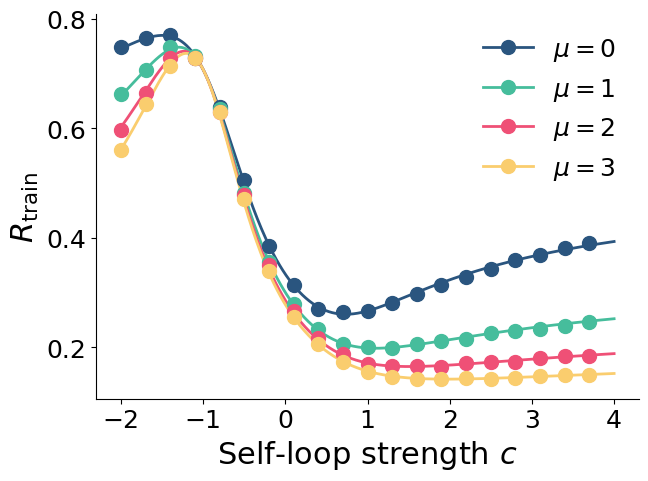

In [12]:
plt.rcParams["figure.figsize"] = (7,5)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()

dashes=[5,3]
legend_list=[]
for i in range(4):
    r_testrisk=re[i]
    p1=ax.errorbar(clist,r_testrisk.mean(axis=1),r_testrisk.std(axis=1),fmt='o',color=color_list[i],capsize=0, elinewidth=2,markersize=10)
    p2=ax.plot(clistT,T[i],'-',color=color_list[i],linewidth=2)
    legend_list.append((p1[0], p2[0]))


ax.legend(legend_list, [r'$\mu=0$',r'$\mu=1$',r'$\mu=2$',r'$\mu=3$'],frameon=False,fontsize=18)
ax.set_ylabel(r'$R_{\mathrm{train}}$',fontsize=22)
ax.set_xlabel(r'Self-loop strength $c$',fontsize=22)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

fig.savefig('f_selfloop_3.pdf',bbox_inches='tight')